In [1]:
from learn_to_infer import Worker
from task import SwitchingBandit
import pandas as pd
import torch
import numpy as np
from optimality import Optimality

from matplotlib import pyplot as plt
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42


In [13]:
from tensorboard.backend.event_processing import event_accumulator
import pandas as pd
import os
import glob

all_losses = []

for id_agent in range(1, 31):
    event_dir = f"results/source/trainings_fullRNN"
    agent_pattern = f"banditGRU_newinit_val_0_beta2_id{id_agent}_init_xavier_optim_Adam_episodeNbMax_50000_numUnits_32_rnnType_GRU_inputType_logodds"
    possible_event_dir = os.path.join(event_dir, agent_pattern)
    # Find event file dynamically in that folder
    event_files = glob.glob(os.path.join(possible_event_dir, "events.out.tfevents.*yggdrasil*"))
    if not event_files:
        print(f"No event files found for agent {id_agent}")
        continue
    event_file = event_files[0]
    ea = event_accumulator.EventAccumulator(
        event_file,
        size_guidance={event_accumulator.SCALARS: 0}
    )
    ea.Reload()
    loss_events = ea.Scalars('Train/marginal_loss')

    times = [e.wall_time for e in loss_events]
    steps = [e.step for e in loss_events]
    values = [e.value for e in loss_events]

    loss_df = pd.DataFrame({
        'wall_time': times,
        'step': steps,
        'loss': values
    })
    loss_df["agent_id"] = id_agent  # Add a column to track the agent

    all_losses.append(loss_df)

loss_df = pd.concat(all_losses, ignore_index=True)

100


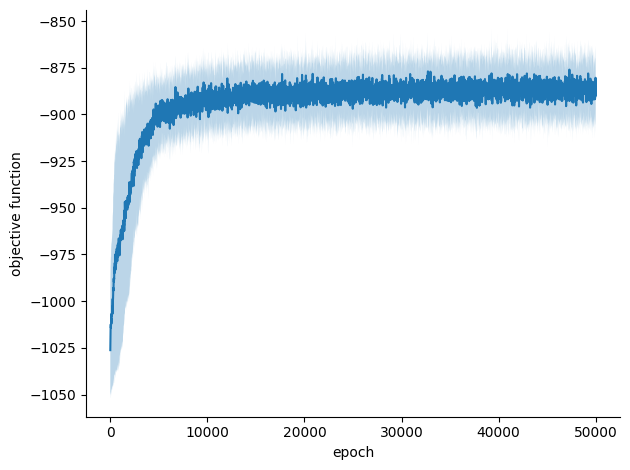

In [14]:
nb_tasks = 100
print(nb_tasks)
import matplotlib.pyplot as plt

loss_stats = loss_df.groupby('step').loss.agg(['mean', 'std'])
fig, ax = plt.subplots()
ax.plot(loss_stats.index, -loss_stats['mean'])
ax.fill_between(loss_stats.index, 
                -loss_stats['mean'] - loss_stats['std'], 
                -loss_stats['mean'] + loss_stats['std'],
                alpha=0.3)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_xlabel('epoch')
ax.set_ylabel('objective function')
plt.tight_layout()
#plt.savefig('figures/loss_epoch_dec2025.pdf')
plt.show()

### time estimation

In [ ]:
index = 10

self = Worker(
    SwitchingBandit(n_trials=500),
    "results/source/saved_models",
    "banditGRU_newinit_val_0_beta2_id{0}".format(index),
)

self.load_model(nb_episodes=50000)

# learn task A
import time
self.env.reset(nb_tasks=100)
start_time = time.time()
result = self.evaluate()
end_time = time.time()
print(f"Time taken: {end_time - start_time} seconds")

### EXAMPLE

In [20]:
from tqdm import tqdm
all_times = []

for index in tqdm(range(1, 31)):
    self = Worker(
        SwitchingBandit(n_trials=500),
        "results/source/saved_models",
        "banditGRU_newinit_val_0_beta2_id{0}".format(index),
    )

    self.load_model(nb_episodes=50000)

    # learn task A
    import time
    np.random.seed(index)
    torch.manual_seed(index)
    self.env.reset(nb_tasks=100)
    start_time = time.time()
    result = self.evaluate()
    end_time = time.time()
    all_times.append(end_time - start_time)

print(f"Time taken: mean {np.mean(all_times)} seconds, std {np.std(all_times)} seconds")

100%|██████████| 30/30 [00:24<00:00,  1.22it/s]

Time taken: mean 0.6381391366322835 seconds, std 0.03817288158458744 seconds


In [4]:
# Sort nus into bins with equal number of points
nb_bins = 10
nus = self.env.nu.mean(axis=1)
sorted_bins = np.percentile(nus, np.linspace(0, 100, nb_bins + 1))
digited_bins = np.digitize(nus, sorted_bins) - 1
nus_native = np.zeros([nb_bins])
nus_learned = np.zeros([nb_bins])
for bin in range(nb_bins):
    print(f"Bin {bin}: {nus[digited_bins == bin].mean()}, n={np.sum(digited_bins == bin)}")
    nus_native[bin] = self.env.nu[digited_bins == bin].mean()
    nus_learned[bin] = result["params_transition"][digited_bins == bin, -1].mean(axis=0).detach().numpy()

Bin 0: 0.005503487371570281, n=100
Bin 1: 0.01647838984448385, n=100
Bin 2: 0.03002442192451956, n=100
Bin 3: 0.04598328638139901, n=100
Bin 4: 0.061443614161104054, n=100
Bin 5: 0.08217152251621145, n=100
Bin 6: 0.10744306902571635, n=100
Bin 7: 0.14101632252254725, n=100
Bin 8: 0.1909646763047354, n=100
Bin 9: 0.27481353393154223, n=99


Text(0, 0.5, 'Inferred mean volatility')

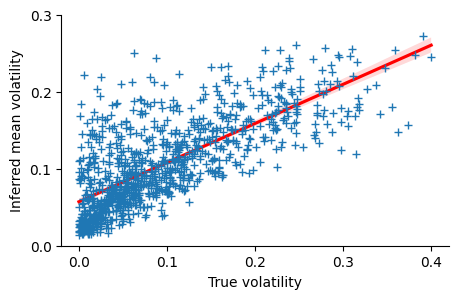

In [5]:
import seaborn as sns

nus = self.env.nu.mean(axis=1)
inferred_vol = [(result["params_transition"].mean(axis=1)[nus == nu]).detach().numpy() for nu in np.unique(nus)]
mean_vol = np.array([np.mean(v) for v in inferred_vol])
std_vol = np.array([np.std(v) for v in inferred_vol])

plt.figure(figsize=(5, 3))
plt.errorbar(np.unique(nus), mean_vol, yerr=std_vol, capsize=0, capthick=0, linestyle='None', marker='+')

# Add linear regression with confidence interval
unique_nus = np.unique(nus)
sns.regplot(x=unique_nus, y=mean_vol, scatter=False, color='red')

plt.ylim([0, 0.3])
plt.gca().set_yticks([0,  0.1, 0.2, 0.3])
plt.gca().set_xticks([0,  0.1, 0.2, 0.3, 0.4])
plt.gca().spines[['right', 'top']].set_visible(False)
plt.xlabel('True volatility')
plt.ylabel('Inferred mean volatility')

In [6]:
# Sort llrmaxs into 10 bins and return bin indices
nb_bins = 5
sorted_bins = np.linspace(self.env.false_positive_feedback.min(), self.env.false_positive_feedback.max(), nb_bins + 1)
digited_bins = np.digitize(self.env.false_positive_feedback, sorted_bins) - 1
p_gen_native = np.zeros([nb_bins, 201])
p_gen_learned = np.zeros([nb_bins, 201])
false_positive_rate = np.zeros([nb_bins])
for bin in range(nb_bins):
    print(f"Bin {bin}: {self.env.false_positive_feedback[digited_bins == bin].mean()}, n={np.sum(digited_bins == bin)}")
    p_gen_native[bin] = self.env.p_gen[digited_bins == bin].mean(axis=0)
    p_gen_learned[bin] = result['params_emission'][digited_bins == bin, -1].mean(axis=0).detach().numpy()
    false_positive_rate[bin] = self.env.p_gen[digited_bins == bin].mean(axis=0)[:50].sum()

Bin 0: 0.05004993583821228, n=260
Bin 1: 0.12498309505496438, n=250
Bin 2: 0.19856914465925804, n=199
Bin 3: 0.2830910102009314, n=161
Bin 4: 0.361684281086931, n=129


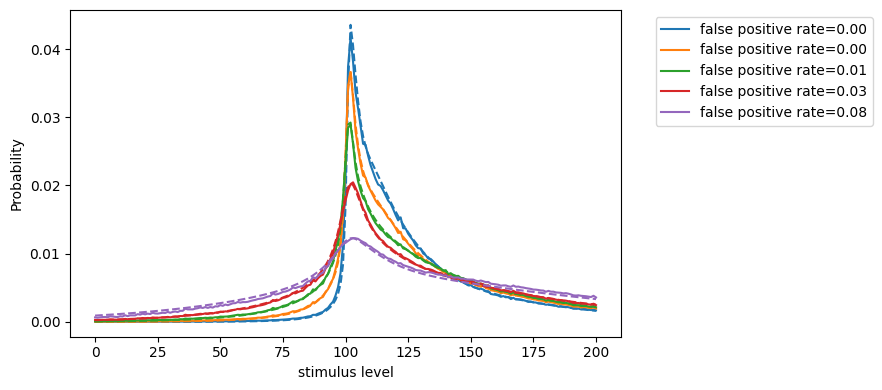

In [7]:
plt.figure(figsize=(9, 4))
for bin in range(nb_bins):
    color = f'C{bin}'
    plt.plot(p_gen_native[bin], '--', color=color)
    plt.plot(p_gen_learned[bin], color=color,
             label=f'false positive rate={false_positive_rate[bin]:.2f}')
plt.xlabel('stimulus level')
plt.ylabel('Probability')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [2]:
import numpy as np

# Define the parameter ranges
range_of_vols = [0.001, 0.01, 0.03, 0.07, 0.13, 0.2, 0.3]
range_of_ffs = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35]
range_of_mus = [0.05, 0.1, 0.15, 0.20, 0.3, 0.45, 0.65]

nb_tasks = 5000
vols_grid, ffs_grid, mus_grid = np.meshgrid(range_of_vols, range_of_ffs, range_of_mus, indexing='ij')
vols, ffs, mus = vols_grid.ravel(), ffs_grid.ravel(), mus_grid.ravel()

nb_repeats = int(nb_tasks / len(vols)) + 1
vols = np.tile(vols, nb_repeats)[:nb_tasks]
ffs = np.tile(ffs, nb_repeats)[:nb_tasks]
mus = np.tile(mus, nb_repeats)[:nb_tasks]

nb_bins_volatility = len(range_of_vols)
nb_bins_falsefeedback = len(range_of_ffs)

In [3]:
from scipy.stats import spearmanr, pearsonr
import warnings
warnings.simplefilter("error", RuntimeWarning)
from tqdm import tqdm
nb_simul = 30
nb_trials = 1000

# performance
performance = np.zeros([nb_simul])
performance_stds = np.zeros([nb_simul])

# volatility
nus_native = np.zeros([nb_simul, nb_bins_volatility])
nus_learned = np.zeros([nb_simul, nb_bins_volatility])
nus_learned_stds = np.zeros([nb_simul, nb_bins_volatility])
out_rewards_nus = np.zeros([nb_simul, nb_bins_volatility])
out_rewards_nus_stds = np.zeros([nb_simul, nb_bins_volatility])
nus_falsefeedback_learned = np.zeros([nb_simul, nb_bins_volatility])
nus_falsefeedback_learned_stds = np.zeros([nb_simul, nb_bins_volatility])
nus_function_of_trials = np.zeros([nb_simul, nb_tasks, nb_trials])

# false feedback
false_positive_rate_native = np.zeros([nb_simul, nb_bins_falsefeedback])
false_positive_rate_learned = np.zeros([nb_simul, nb_bins_falsefeedback])
false_positive_rate_learned_stds = np.zeros([nb_simul, nb_bins_falsefeedback])
out_rewards_falsefeedback = np.zeros([nb_simul, nb_bins_falsefeedback])
out_rewards_falsefeedback_stds = np.zeros([nb_simul, nb_bins_falsefeedback])
false_positive_rate_nus_learned = np.zeros([nb_simul, nb_bins_falsefeedback])
false_positive_rate_nus_learned_stds = np.zeros([nb_simul, nb_bins_falsefeedback])
false_positive_rate_function_of_trials = np.zeros([nb_simul, nb_tasks, nb_trials])
reversal_falsepositive_means = np.zeros([nb_simul, nb_bins_falsefeedback, 20])
reversal_falsepositive_stds = np.zeros([nb_simul, nb_bins_falsefeedback, 20])

# mean emission
nb_bins_mus = 7
mus_native = np.zeros([nb_simul, nb_bins_mus])
mus_learned = np.zeros([nb_simul, nb_bins_mus])
mus_learned_stds = np.zeros([nb_simul, nb_bins_mus])
emission_function_of_trials = np.zeros([nb_simul, nb_tasks, 10, 201])

# reversals
reversal_performance_means = np.zeros([nb_simul, nb_bins_volatility, 20])
reversal_performance_stds = np.zeros([nb_simul, nb_bins_volatility, 20])

for index in tqdm(range(1, nb_simul + 1)):

    self = Worker(
        SwitchingBandit(n_trials=nb_trials),
        "results/source/saved_models",
        "banditGRU_newinit_val_0_beta2_id{0}".format(index),
    )

    self.load_model(nb_episodes=50000)

    np.random.seed(0)
    torch.manual_seed(0)
    self.env.reset(nb_tasks=nb_tasks, nus=vols, ffs=ffs, mus=mus)
    result = self.evaluate(use_ground_truth=False)

    # volatility
    nus = self.env.nu.mean(axis=1)
    sorted_bins = np.array([0] + range_of_vols) + 1e-9
    digited_bins = np.digitize(nus, sorted_bins, right=True) - 1
    digited_bins[digited_bins == nb_bins_volatility] = nb_bins_volatility - 1 # bin nb_bins_volatility-1 is skipped
    for bin in range(nb_bins_volatility):
        nus_native[index - 1, bin] = self.env.nu[digited_bins == bin].mean()
        nus_learned[index - 1, bin] = result["params_transition"][digited_bins == bin, -1].mean(axis=0).detach().numpy()
        nus_learned_stds[index - 1, bin] = result["params_transition"][digited_bins == bin, -1].std(axis=0).detach().numpy()
        nus_falsefeedback_learned[index - 1, bin] = result['params_emission'][digited_bins == bin, -1, :100].sum(-1).mean(axis=0).detach().numpy()
        nus_falsefeedback_learned_stds[index - 1, bin] = result['params_emission'][digited_bins == bin, -1, :100].sum(-1).std(axis=0).detach().numpy()
    nus_function_of_trials[index - 1, :] = result["params_transition"].detach().numpy()

    # rewards x volatility
    chosen_correct_action = (result['actions'].detach().numpy() == self.env.correct_arms)
    obtained_rewards = [chosen_correct_action[digited_bins == nu] for nu in range(nb_bins_volatility)]
    out_rewards_nus[index - 1, :] = np.array([np.mean(v) for v in obtained_rewards])
    out_rewards_nus_stds[index - 1, :] = np.array([np.std(v) for v in obtained_rewards])

    # false feedback
    false_positive_rate = self.env.false_positive_feedback
    sorted_bins_falsefeedback = np.array([0] + range_of_ffs) + 1e-9
    digited_bins_falsefeedback = np.digitize(self.env.false_positive_feedback, sorted_bins_falsefeedback, right=True) - 1
    assert((digited_bins_falsefeedback != nb_bins_falsefeedback).all())
    digited_bins_falsefeedback[digited_bins_falsefeedback == nb_bins_falsefeedback] = nb_bins_falsefeedback - 1 # bin nb_bins_falsefeedback-1 is skipped
    for bin in range(nb_bins_falsefeedback):
        false_positive_rate_native[index - 1, bin] = self.env.p_gen[digited_bins_falsefeedback == bin, :100].sum(-1).mean(axis=0)
        false_positive_rate_learned[index - 1, bin] = result['params_emission'][digited_bins_falsefeedback == bin, -1, :100].sum(-1).mean(axis=0).detach().numpy()
        false_positive_rate_learned_stds[index - 1, bin] = result['params_emission'][digited_bins_falsefeedback == bin, -1, :100].sum(-1).std(axis=0).detach().numpy()
        false_positive_rate_nus_learned[index - 1, bin] = result['params_transition'][digited_bins_falsefeedback == bin, -1].mean(axis=0).detach().numpy()
        false_positive_rate_nus_learned_stds[index - 1, bin] = result['params_transition'][digited_bins_falsefeedback == bin, -1].std(axis=0).detach().numpy()
    false_positive_rate_function_of_trials[index - 1, :] = result['params_emission'][:, :, :100].sum(-1).detach().numpy()
    emission_function_of_trials[index - 1] = result['params_emission'][:, np.array([0, 10, 20, 30, 40, 50, 60, 70, 100, -1]), :].detach().numpy()

    # mus
    mus = self.env.mus
    sorted_bins_mus = np.array([0] + range_of_mus) + 1e-9
    digited_bins_mus = np.digitize(mus, sorted_bins_mus, right=True) - 1
    stimulus_range = np.linspace(-1, 1.01, 201)
    for bin in range(nb_bins_mus):
        mus_native[index - 1, bin] = self.env.mus[digited_bins_mus == bin].mean()
        mus_learned[index - 1, bin] = (result['params_emission'][digited_bins_mus == bin, -1].detach().numpy() * stimulus_range[None]).sum(axis=-1).mean()
        
    # rewards x false feedback
    chosen_correct_action = (result['actions'].detach().numpy() == self.env.correct_arms)
    obtained_rewards = [chosen_correct_action[digited_bins_falsefeedback == ff] for ff in range(nb_bins_falsefeedback)]
    out_rewards_falsefeedback[index - 1, :] = np.array([np.mean(v) for v in obtained_rewards])
    out_rewards_falsefeedback_stds[index - 1, :] = np.array([np.std(v) for v in obtained_rewards])

    # reversal performance
    chosen_correct_action = (result['actions'].detach().numpy() == self.env.correct_arms)
    performance[index - 1] = chosen_correct_action.mean()
    performance_stds[index - 1] = chosen_correct_action.std()

    reversal_xx, reversal_yy = np.where((self.env.correct_arms[:, 5:-15] != self.env.correct_arms[:, 4:-16]) * (self.env.false_positive_feedback[:, None] == 0.2))
    reversal_yy = reversal_yy + 5

    reversal_performance = np.zeros([nb_bins_volatility, len(reversal_xx), 20]) + np.nan
    for i, (xx, yy) in enumerate(zip(reversal_xx, reversal_yy)):
        if yy > (nb_trials / 2):
            yy_min = max(yy - 5, 0, reversal_yy[i-1]) if (i > 0) and (reversal_xx[i-1] == reversal_xx[i]) else max(yy - 5, 0)
            yy_max = min(yy + 15, nb_trials, reversal_yy[i+1]) if (i < len(reversal_yy) - 1) and (reversal_xx[i+1] == reversal_xx[i]) else min(yy + 15, nb_trials)
            reversal_performance[digited_bins[xx], i, :] = chosen_correct_action[xx, (yy-5):(yy + 15)]
    reversal_performance_means[index - 1, :, :] = np.nanmean(reversal_performance, axis=1)
    reversal_performance_stds[index - 1, :, :] = np.nanstd(reversal_performance, axis=1)

    # false positive rate x false feedback
    reversal_xx, reversal_yy = np.where((self.env.correct_arms[:, 5:-15] != self.env.correct_arms[:, 4:-16]) * (self.env.nu[:, 0][:, None] == 0.03))
    reversal_yy = reversal_yy + 5

    reversal_falsepositive = np.zeros([nb_bins_falsefeedback, len(reversal_xx), 20]) + np.nan
    for i, (xx, yy) in enumerate(zip(reversal_xx, reversal_yy)):
        if yy > (nb_trials / 2):
            yy_min = max(yy - 5, 0, reversal_yy[i-1]) if (i > 0) and (reversal_xx[i-1] == reversal_xx[i]) else max(yy - 5, 0)
            yy_max = min(yy + 15, nb_trials, reversal_yy[i+1]) if (i < len(reversal_yy) - 1) and (reversal_xx[i+1] == reversal_xx[i]) else min(yy + 15, nb_trials)
            reversal_falsepositive[digited_bins_falsefeedback[xx], i, :] = chosen_correct_action[xx, (yy-5):(yy + 15)]
    reversal_falsepositive_means[index - 1, :, :] = np.nanmean(reversal_falsepositive, axis=1)
    reversal_falsepositive_stds[index - 1, :, :] = np.nanstd(reversal_falsepositive, axis=1)    

100%|██████████| 30/30 [24:37<00:00, 49.25s/it]


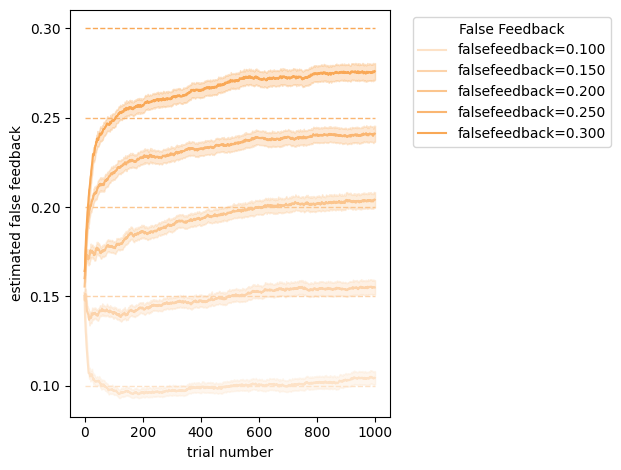

In [18]:
unique_falsefeedback = np.unique(ffs)[1:-1]
estimations_means = np.hstack([false_positive_rate_function_of_trials[:, (ffs==v) * (vols==0.03)].mean(axis=1, keepdims=True) for v in unique_falsefeedback])

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# Create a colormap gradient of "#F8993A"
base_color = "#F8993A"
# We'll make a light-to-dark gradient using the base color and white
colors = [mcolors.to_rgba(base_color, alpha=1.0)]
for i in range(1, estimations_means.shape[1] + 2):
    # Interpolate between white and base_color
    interp = i / (estimations_means.shape[1] + 2)
    color = mcolors.to_rgba(base_color, alpha=1.0)
    white = np.array([1, 1, 1, 1])
    color = tuple((1 - interp) * white + interp * np.array(color))
    colors.append(color)
# Use the list of colors as gradient

for i in range(estimations_means.shape[1]):
    color = colors[i + 2]  # skip the lightest colors (to avoid pure white)
    plt.plot(estimations_means[:, i, 1:1000].mean(axis=0), color=color, label=f'falsefeedback={unique_falsefeedback[i]:.3f}')
    plt.fill_between(np.arange(1, 1000), 
        estimations_means[:, i, 1:1000].mean(axis=0) - estimations_means[:, i, 1:1000].std(axis=0) / np.sqrt(estimations_means.shape[0]), 
        estimations_means[:, i, 1:1000].mean(axis=0) + estimations_means[:, i, 1:1000].std(axis=0) / np.sqrt(estimations_means.shape[0]), 
        color=color, alpha=0.3)
    plt.plot([0, 1000], [unique_falsefeedback[i], unique_falsefeedback[i]], color=color, linestyle='--', linewidth=1)
plt.xlabel('False Feedback Rate')
plt.legend(title="False Feedback", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel('trial number')
plt.ylabel('estimated false feedback')
plt.tight_layout()
#plt.savefig('figures/falsefeedback_trial_number_feb2026.pdf')

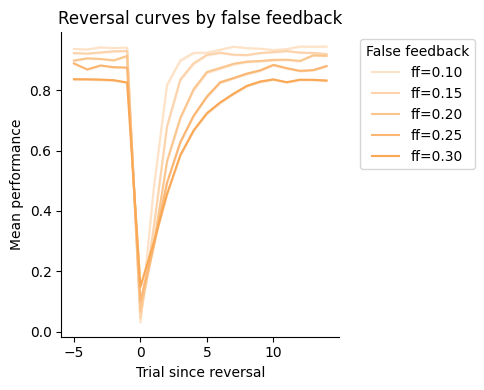

In [19]:
import matplotlib.cm as cm

fig, ax = plt.subplots(figsize=(5, 4))

x_ffs = np.unique(ffs)[1:-1]

# Create the Blues colormap with enough bins for each volatility value

for i in range(1, nb_bins_falsefeedback - 1):
    color = colors[i + 1]  # Skip the lightest blues
    avg_reversal_performance = reversal_falsepositive_means[:, i].mean(axis=0)
    std_reversal_performance = reversal_falsepositive_stds[:, i].std(axis=0) / np.sqrt(reversal_falsepositive_stds.shape[0])
    xvals = np.arange(-5, 15)
    ax.plot(xvals, avg_reversal_performance, color=color, label=f'ff={x_ffs[i - 1]:.2f}')
    ax.fill_between(
        xvals,
        avg_reversal_performance - std_reversal_performance,
        avg_reversal_performance + std_reversal_performance,
        color=color,
        alpha=0.3
    )
ax.set_xlabel('Trial since reversal')
ax.set_ylabel('Mean performance')
ax.set_title('Reversal curves by false feedback')
ax.legend(title='False feedback', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
#plt.savefig("figures/reversal_curves_falsefeedback_feb2026.pdf")
plt.show()


/var/folders/5j/f0qqpk592x36fxmyl_8vbkw40000gp/T/ipykernel_56898/3514983202.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Blues', nb_bins_volatility + 2)  # +2 to avoid pure white


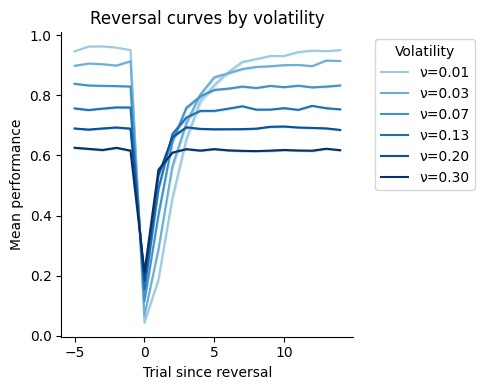

In [20]:
import matplotlib.cm as cm

fig, ax = plt.subplots(figsize=(5, 4))
x_nus = np.unique(nus)

# Create the Blues colormap with enough bins for each volatility value
cmap = cm.get_cmap('Blues', nb_bins_volatility + 2)  # +2 to avoid pure white

for i in range(1, nb_bins_volatility):
    color = cmap(i + 2)  # Skip the lightest blues
    avg_reversal_performance = reversal_performance_means[:, i].mean(axis=0)
    std_reversal_performance = reversal_performance_means[:, i].std(axis=0) / np.sqrt(reversal_performance_means.shape[0])
    xvals = np.arange(-5, 15)
    ax.plot(xvals, avg_reversal_performance, color=color, label=f'ν={x_nus[i]:.2f}')
    ax.fill_between(
        xvals,
        avg_reversal_performance - std_reversal_performance,
        avg_reversal_performance + std_reversal_performance,
        color=color,
        alpha=0.3
    )
ax.set_xlabel('Trial since reversal')
ax.set_ylabel('Mean performance')
ax.set_title('Reversal curves by volatility')
ax.legend(title='Volatility', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
#plt.savefig("figures/reversal_curves_feb2026.pdf")
plt.show()


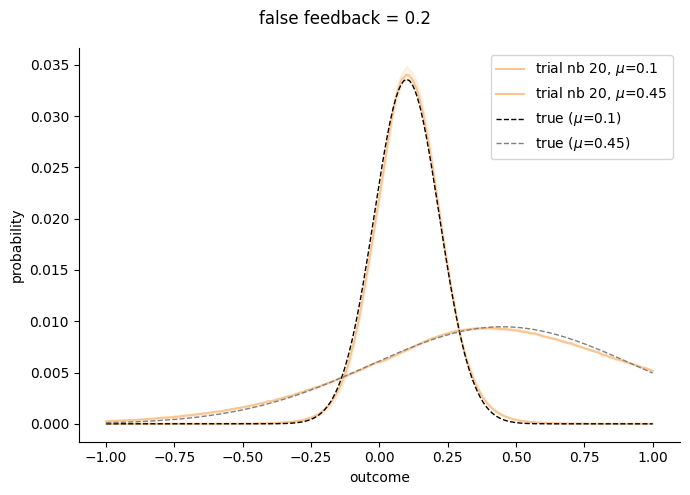

In [21]:
import matplotlib.colors as mcolors
import numpy as np
import matplotlib.pyplot as plt

# Set rcParams for editable text in PDF
plt.rcParams.update({
    "pdf.fonttype": 42,  # Use TrueType fonts for editable text in PDF
    "ps.fonttype": 42,
})

base_color = "#FAC58E"

falsefeedback_id = 2
falsefeedback = np.unique(ffs)[1:-1][falsefeedback_id]

# Prepare the first set (mu=0.1)
mu1 = 0.1
unique_falsefeedback = np.unique(ffs)[1:-1]
subemissions1 = np.hstack([
    emission_function_of_trials[:, (vols==0.13) & (mus==mu1) & (ffs==f)][:, :, np.array([2])].mean(axis=1, keepdims=True)
    for f in unique_falsefeedback
])
native1 = np.vstack([self.env.p_gen[(vols==0.13) & (mus==mu1) & (ffs==f)].mean(axis=0, keepdims=True) for f in unique_falsefeedback])

# Prepare the second set (mu=0.45)
mu2 = 0.45
subemissions2 = np.hstack([
    emission_function_of_trials[:, (vols==0.13) & (mus==mu2) & (ffs==f)][:, :, np.array([2])].mean(axis=1, keepdims=True)
    for f in unique_falsefeedback
])
native2 = np.vstack([self.env.p_gen[(vols==0.13) & (mus==mu2) & (ffs==f)].mean(axis=0, keepdims=True) for f in unique_falsefeedback])

x_range = np.arange(-1, 1.01, 0.01)
iterations = [20]
num_iters = len(iterations)

fig, ax = plt.subplots(figsize=(7, 5))

# Use the same colors for both mus (solid for mu1, dashed for mu2)
# mu=0.1 solid
ax.plot(
    x_range,
    subemissions1[:, falsefeedback_id, 0].mean(axis=0),
    color=base_color,
    alpha=1.0,
    label=f'trial nb {iterations[0]}, $\mu$={mu1}',
    zorder=2+0
)
ax.fill_between(
    x_range,
    np.quantile(subemissions1[:, falsefeedback_id, 0], 0.25, axis=0),
    np.quantile(subemissions1[:, falsefeedback_id, 0], 0.75, axis=0),
    color=base_color,
    alpha=0.2,
    zorder=2+0
)

# mu=0.45 dashed, same color
ax.plot(
    x_range,
    subemissions2[:, falsefeedback_id, 0].mean(axis=0),
    color=base_color,
    linestyle="-",
    alpha=1.0,
    label=f'trial nb {iterations[0]}, $\mu$={mu2}',
    zorder=6+0
)
ax.fill_between(
    x_range,
    np.quantile(subemissions2[:, falsefeedback_id, 0], 0.25, axis=0),
    np.quantile(subemissions2[:, falsefeedback_id, 0], 0.75, axis=0),
    color=base_color,
    alpha=0.15,
    zorder=6+0
)
ax.plot(x_range, native1[falsefeedback_id], "--", color='black', lw=1, label=f"true ($\mu$={mu1})", zorder=9)
ax.plot(x_range, native2[falsefeedback_id], "--", color='gray', lw=1, label=f"true ($\mu$={mu2})", zorder=20)

ax.set_ylabel('probability')
ax.set_xlabel('outcome')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.suptitle(f'false feedback = {falsefeedback}')
plt.tight_layout()
#plt.savefig('figures/falsefeedback_outcome_feb2026.pdf')

/var/folders/5j/f0qqpk592x36fxmyl_8vbkw40000gp/T/ipykernel_56898/2011117473.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Blues', n_bins + 2)  # +2 to not have white


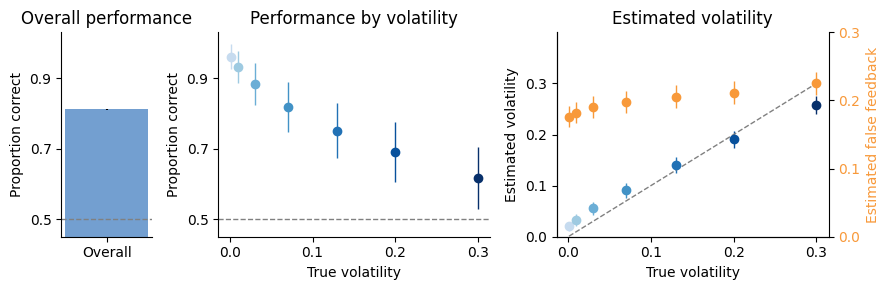

In [22]:
x_nus = np.unique(nus)

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

fig, axs = plt.subplots(1, 3, figsize=(9, 3), gridspec_kw={'width_ratios': [1, 3, 3]})

# Subplot 1: overall performance barplot
overall_mean = performance.mean()
overall_std = performance.std() / np.sqrt(nb_simul)
axs[0].bar(0, overall_mean, yerr=overall_std, color="#3877BC", capsize=0, alpha=0.7)
axs[0].axhline(0.5, color='gray', linestyle='--', linewidth=1)
axs[0].set_ylim([0.45, 1.03])
axs[0].set_yticks([0.5, 0.7, 0.9])
axs[0].set_xticks([0])
axs[0].set_xticklabels(['Overall'])
axs[0].spines[['right', 'top']].set_visible(False)
axs[0].set_ylabel('Proportion correct')
axs[0].set_title('Overall performance')

# Subplot 2: errorbars by volatility (blues gradient for each)
mean_rewards = out_rewards_nus.mean(axis=0)
std_rewards = out_rewards_nus_stds.mean(axis=0) / np.sqrt(nb_simul)
n_bins = len(x_nus)
cmap = cm.get_cmap('Blues', n_bins + 2)  # +2 to not have white
vol_lines = []

for i in range(n_bins):
    color = cmap(i + 2)  # skip first two lightest
    h = axs[1].errorbar(
        x_nus[i],
        mean_rewards[i],
        yerr=std_rewards[i],
        fmt='o',
        color=color,
        ecolor=color,
        elinewidth=1,
        capsize=0,
        label=f'vol={x_nus[i]:.3f}' if i < 8 else None # only a few for legend
    )
    vol_lines.append(h)
axs[1].axhline(0.5, color='gray', linestyle='--', linewidth=1)
axs[1].set_ylim([0.45, 1.03])
axs[1].set_yticks([0.5, 0.7, 0.9])
axs[1].spines[['right', 'top']].set_visible(False)
axs[1].set_xlabel('True volatility')
axs[1].set_ylabel('Proportion correct')
axs[1].set_title('Performance by volatility')
# Optionally: legend for colors in subplot 2
# axs[1].legend(loc="upper left", bbox_to_anchor=(1.05, 1), title="Volatility")

# Subplot 3: errorbars for estimated volatility (blues) and false feedback (orange, right)
mean_vol = nus_learned.mean(axis=0)
mean_falsefeedback = nus_falsefeedback_learned.mean(axis=0)
std_vol = nus_learned_stds.mean(axis=0) / np.sqrt(nb_simul)
std_falsefeedback = nus_falsefeedback_learned_stds.mean(axis=0) / np.sqrt(nb_simul)

ax3 = axs[2]
ax3b = ax3.twinx()

vol_lines_third = []
for i in range(n_bins):
    color = cmap(i + 2)
    h = ax3.errorbar(
        x_nus[i],
        mean_vol[i],
        yerr=std_vol[i],
        fmt='o',
        color=color,
        ecolor=color,
        elinewidth=1,
        capsize=0,
        label=f'vol={x_nus[i]:.3f}' if i < 8 else None
    )
    vol_lines_third.append(h)
ax3.plot(x_nus, x_nus, color='gray', linestyle='--', linewidth=1, label='x = y')
ax3.set_yticks([0, 0.1, 0.2, 0.3])
ax3.set_xticks([0, 0.1, 0.2, 0.3])
ax3.set_ylim([0, 0.4])
ax3.spines[['right', 'top']].set_visible(False)
ax3.set_xlabel('True volatility')
ax3.set_ylabel('Estimated volatility')
ax3.set_title('Estimated volatility')

# Estimated false feedback errorbars (orange, right axis)
ax3b.errorbar(
    x_nus,
    mean_falsefeedback,
    yerr=std_falsefeedback,
    fmt='o',
    color="#F8993A",
    ecolor="#F8993A",
    elinewidth=1,
    capsize=0,
    label='Estimated false feedback'
)
ax3b.set_ylabel("Estimated false feedback", color="#F8993A")
ax3b.tick_params(axis='y', labelcolor="#F8993A")
ax3b.spines['top'].set_visible(False)
ax3b.set_yticks([0, 0.1, 0.2, 0.3])

# Optionally: show legend for the different blues
# Only label the first line to not overload the legend, or label each if desired:
# handles = [vol_lines_third[0].lines[0]]
# labels = [f"volatility bins" ]
# lines2, labels2 = ax3.get_legend_handles_labels()
# ax3.legend(lines2, labels2, loc="upper left")

plt.tight_layout()
#plt.savefig("figures/estimated_mean_volatility_feb2026.pdf")
plt.show()

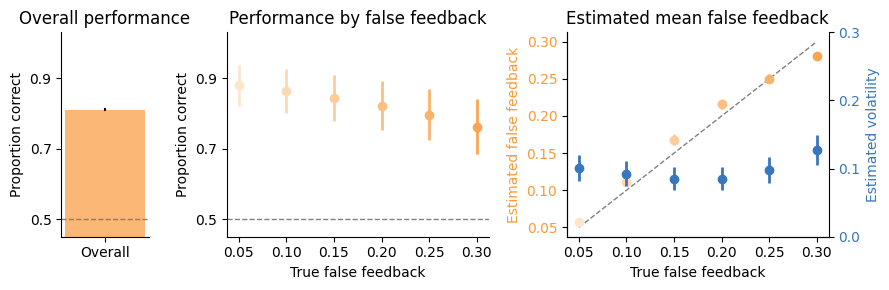

In [23]:
#sorted_bins = np.percentile(false_positive_rate, np.linspace(0, 100, nb_bins_falsefeedback + 1))
x_falsefeedback = np.unique(false_positive_rate)[:-1] #(sorted_bins[:-1] + sorted_bins[1:]) / 2.

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

fig, axs = plt.subplots(1, 3, figsize=(9, 3), gridspec_kw={'width_ratios': [1, 3, 3]})

# Subplot 1: overall performance barplot
overall_mean = out_rewards_falsefeedback.mean()
overall_std = out_rewards_falsefeedback.std() / np.sqrt(out_rewards_falsefeedback.size)
axs[0].bar(0, overall_mean, yerr=overall_std, color="#F8993A", capsize=0, alpha=0.7)
axs[0].axhline(0.5, color='gray', linestyle='--', linewidth=1)
axs[0].set_ylim([0.45, 1.03])
axs[0].set_yticks([0.5, 0.7, 0.9])
axs[0].set_xticks([0])
axs[0].set_xticklabels(['Overall'])
axs[0].spines[['right', 'top']].set_visible(False)
axs[0].set_ylabel('Proportion correct')
axs[0].set_title('Overall performance')

# Subplot 2: errorbars by false feedback (individual colored errorbars)
base_color = "#F8993A"
n_bins_ffb = len(x_falsefeedback)
colors = [mcolors.to_rgba(base_color, alpha=1.0)]
for i in range(1, n_bins_ffb + 2):
    interp = i / (n_bins_ffb + 2)
    color = mcolors.to_rgba(base_color, alpha=1.0)
    white = np.array([1, 1, 1, 1])
    color = tuple((1 - interp) * white + interp * np.array(color))
    colors.append(color)
errorbar_colors = [colors[i + 2] for i in range(n_bins_ffb)]  # skip lightest

mean_rewards = out_rewards_falsefeedback.mean(axis=0)
std_rewards = out_rewards_falsefeedback_stds.mean(axis=0) / np.sqrt(nb_simul)
for i, (x, m, s) in enumerate(zip(x_falsefeedback, mean_rewards, std_rewards)):
    axs[1].errorbar(
        x, m, yerr=s, fmt='o',
        color=errorbar_colors[i],
        ecolor=errorbar_colors[i],
        elinewidth=2,
        capsize=0,
    )
axs[1].axhline(0.5, color='gray', linestyle='--', linewidth=1)
axs[1].set_ylim([0.45, 1.03])
axs[1].set_yticks([0.5, 0.7, 0.9])
axs[1].spines[['right', 'top']].set_visible(False)
axs[1].set_xlabel('True false feedback')
axs[1].set_ylabel('Proportion correct')
axs[1].set_title('Performance by false feedback')

# Subplot 3: errorbars for inferred false feedback (estimates) and volatility estimate errorbars (blue)
mean_ffb = false_positive_rate_learned.mean(axis=0)
std_ffb = false_positive_rate_learned_stds.mean(axis=0) / np.sqrt(nb_simul)
for i, (x, m, s) in enumerate(zip(x_falsefeedback, mean_ffb, std_ffb)):
    axs[2].errorbar(
        x, m, yerr=s, fmt='o',
        color=errorbar_colors[i],
        ecolor=errorbar_colors[i],
        elinewidth=2,
        capsize=0,
        label=f"Estimated false feedback {x:.2f}" if i == 0 else None,  # label only once for legend
    )
axs[2].plot(x_falsefeedback, x_falsefeedback, color='gray', linestyle='--', linewidth=1, label='x = y')

# Volatility estimate as errorbars, as requested
mean_nu = false_positive_rate_nus_learned.mean(axis=0)
std_nu = false_positive_rate_nus_learned_stds.mean(axis=0) / np.sqrt(nb_simul)
axs2_right = axs[2].twinx()
for i, (x, m, s) in enumerate(zip(x_falsefeedback, mean_nu, std_nu)):
    axs2_right.errorbar(
        x, m, yerr=s, fmt='o',
        color="#3877BC",
        ecolor="#3877BC",
        elinewidth=2,
        capsize=0,
        label="Estimated volatility" if i == 0 else None,
    )

axs2_right.set_ylabel("Estimated volatility", color="#3877BC")
axs2_right.tick_params(axis='y', labelcolor="#3877BC")
axs2_right.spines['top'].set_visible(False)
axs2_right.set_yticks([0, 0.1, 0.2, 0.3])  # adjust y-ticks as needed
axs2_right.set_ylim([0, 0.3])

axs[2].spines[['right', 'top']].set_visible(False)
axs[2].set_xlabel('True false feedback')
axs[2].set_ylabel('Estimated false feedback', color="#F8993A")
axs[2].set_title('Estimated mean false feedback')
axs[2].tick_params(axis='y', labelcolor="#F8993A")



plt.tight_layout()
#plt.savefig("figures/estimated_false_feedback_feb2026.pdf")
plt.show()

### Compared to optimality

In [24]:
from optimality import Optimality
import pickle
#[dict_optim, opt] = pickle.load(open("result_optimality_1.pkl", "rb"))
[dict_optim, opt] = pickle.load(open("result_optimality_symmetric.pkl", "rb"))

In [25]:
nb_simul_optim = 1
# performance
performance_optim = np.zeros([nb_simul_optim])

# volatility
nus_native_optim = np.zeros([nb_simul_optim, nb_bins_volatility])
nus_learned_optim = np.zeros([nb_simul_optim, nb_bins_volatility])
out_rewards_nus_optim = np.zeros([nb_simul_optim, nb_bins_volatility])
nus_falsefeedback_learned_optim = np.zeros([nb_simul_optim, nb_bins_volatility])
nus_function_of_trials_optim = np.zeros([nb_simul_optim, nb_tasks, nb_trials])

# false feedback
false_positive_rate_native_optim = np.zeros([nb_simul_optim, nb_bins_falsefeedback])
false_positive_rate_learned_optim = np.zeros([nb_simul_optim, nb_bins_falsefeedback])
out_rewards_falsefeedback_optim = np.zeros([nb_simul_optim, nb_bins_falsefeedback])
false_positive_rate_nus_learned_optim = np.zeros([nb_simul_optim, nb_bins_falsefeedback])
false_positive_rate_function_of_trials_optim = np.zeros([nb_simul_optim, nb_tasks, nb_trials])

# volatility
nus = self.env.nu.mean(axis=1)
sorted_bins = np.array([0] + range_of_vols) + 1e-9
digited_bins = np.digitize(nus, sorted_bins, right=True) - 1
digited_bins[digited_bins == nb_bins_volatility] = nb_bins_volatility - 1 # bin nb_bins_volatility-1 is skipped

# false feedback
false_positive_rate = self.env.false_positive_feedback
sorted_bins_falsefeedback = np.array([0] + range_of_ffs) + 1e-9
digited_bins_falsefeedback = np.digitize(self.env.false_positive_feedback, sorted_bins_falsefeedback, right=True) - 1
assert((digited_bins_falsefeedback != nb_bins_falsefeedback).all())
digited_bins_falsefeedback[digited_bins_falsefeedback == nb_bins_falsefeedback] = nb_bins_falsefeedback - 1 # bin nb_bins_falsefeedback-1 is skipped

# rewards x volatility
#chosen_correct_actions_optim = (dict_optim['actions'] == self.env.correct_arms)
performance_optim = dict_optim['correct_response'].mean()#chosen_correct_actions_optim.mean()
obtained_rewards_optim = [dict_optim['correct_response'][digited_bins == nu] for nu in range(nb_bins_volatility)]
out_rewards_nus_optim[0, :] = np.array([np.mean(v) for v in obtained_rewards_optim])

obtained_rewards_falsefeedback_optim = [dict_optim['correct_response'][digited_bins_falsefeedback == nu] for nu in range(nb_bins_falsefeedback)]
out_rewards_falsefeedback_optim[0, :] = np.array([np.mean(v) for v in obtained_rewards_falsefeedback_optim])

for bin in range(nb_bins_volatility):
    nus_native_optim[0, bin] = self.env.nu[digited_bins == bin].mean()
    nus_learned_optim[0, bin] = dict_optim["params_transition"][digited_bins == bin, -1].mean(axis=0)
    nus_falsefeedback_learned_optim[0, bin] = dict_optim['false_positive_rate'][digited_bins == bin, -1].mean(axis=0)
nus_function_of_trials_optim[0, :] = dict_optim["params_transition"]

# false feedback
for bin in range(nb_bins_falsefeedback):
    false_positive_rate_native_optim[0, bin] = self.env.p_gen[digited_bins_falsefeedback == bin, :100].sum(-1).mean(axis=0)
    false_positive_rate_learned_optim[0, bin] = dict_optim['false_positive_rate'][digited_bins_falsefeedback == bin, -1].mean(axis=0)
    false_positive_rate_nus_learned_optim[0, bin] = dict_optim['params_transition'][digited_bins_falsefeedback == bin, -1].mean(axis=0)
false_positive_rate_function_of_trials_optim[0, :] = dict_optim['false_positive_rate']

/var/folders/5j/f0qqpk592x36fxmyl_8vbkw40000gp/T/ipykernel_4563/2428285361.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Blues', estimations_means.shape[1] + 2)  # +2 to avoid pure white


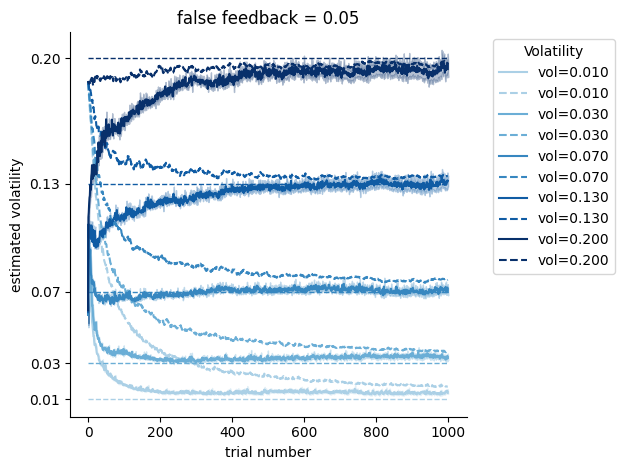

In [21]:
unique_vols = np.unique(vols)[1:-1]
estimations_means = np.hstack([nus_function_of_trials[:, (vols==v) * (ffs==0.05)].mean(axis=1, keepdims=True) for v in unique_vols])
estimations_means_optim = np.hstack([nus_function_of_trials_optim[:, (vols==v) * (ffs==0.05)].mean(axis=1, keepdims=True) for v in unique_vols])

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Create a colormap with as many shades as unique_vols
cmap = cm.get_cmap('Blues', estimations_means.shape[1] + 2)  # +2 to avoid pure white

fig, ax = plt.subplots()
for i in range(estimations_means.shape[1]):
    color = cmap(i + 2)  # skip the lightest colors
    ax.plot(estimations_means[:, i, 1:1000].mean(axis=0), color=color, label=f'vol={unique_vols[i]:.3f}')
    ax.plot(estimations_means_optim[:, i, 1:1000].mean(axis=0), '--', color=color, label=f'vol={unique_vols[i]:.3f}')
    ax.fill_between(np.arange(1, 1000), 
        estimations_means[:, i, 1:1000].mean(axis=0) - estimations_means[:, i, 1:1000].std(axis=0) / np.sqrt(estimations_means.shape[0]), 
        estimations_means[:, i, 1:1000].mean(axis=0) + estimations_means[:, i, 1:1000].std(axis=0) / np.sqrt(estimations_means.shape[0]), 
        color=color, alpha=0.3)
    ax.plot([0, 1000], [unique_vols[i], unique_vols[i]], color=color, linestyle='--', linewidth=1)
ax.set_xlabel('True volatility')
ax.legend(title="Volatility", bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xlabel('trial number')
ax.set_ylabel('estimated volatility')
ax.set_title('false feedback = 0.05')
ax.set_yticks(unique_vols)
# Take out top and right edges
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('figures/volatility_trial_number_april2026_optimal.pdf')

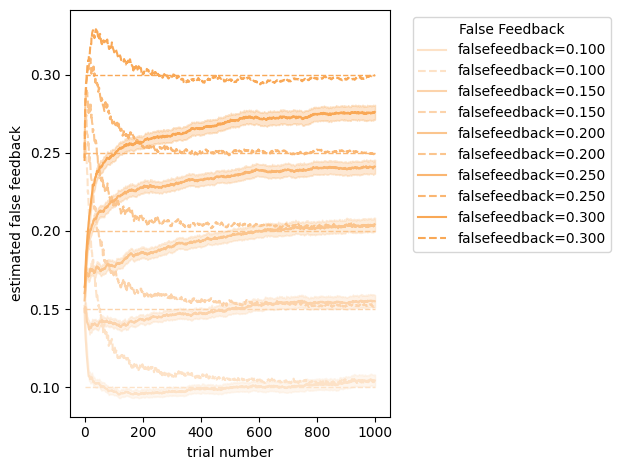

In [22]:
unique_falsefeedback = np.unique(ffs)[1:-1]
estimations_means = np.hstack([false_positive_rate_function_of_trials[:, (ffs==v) * (vols==0.03)].mean(axis=1, keepdims=True) for v in unique_falsefeedback])
estimations_means_optim = np.hstack([false_positive_rate_function_of_trials_optim[:, (ffs==v) * (vols==0.03)].mean(axis=1, keepdims=True) for v in unique_falsefeedback])

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# Create a colormap gradient of "#F8993A"
base_color = "#F8993A"
# We'll make a light-to-dark gradient using the base color and white
colors = [mcolors.to_rgba(base_color, alpha=1.0)]
for i in range(1, estimations_means.shape[1] + 2):
    # Interpolate between white and base_color
    interp = i / (estimations_means.shape[1] + 2)
    color = mcolors.to_rgba(base_color, alpha=1.0)
    white = np.array([1, 1, 1, 1])
    color = tuple((1 - interp) * white + interp * np.array(color))
    colors.append(color)
# Use the list of colors as gradient

for i in range(estimations_means.shape[1]):
    color = colors[i + 2]  # skip the lightest colors (to avoid pure white)
    plt.plot(estimations_means[:, i, 1:1000].mean(axis=0), color=color, label=f'falsefeedback={unique_falsefeedback[i]:.3f}')
    plt.plot(estimations_means_optim[:, i, 1:1000].mean(axis=0), '--', color=color, label=f'falsefeedback={unique_falsefeedback[i]:.3f}')
    plt.fill_between(np.arange(1, 1000), 
        estimations_means[:, i, 1:1000].mean(axis=0) - estimations_means[:, i, 1:1000].std(axis=0) / np.sqrt(estimations_means.shape[0]), 
        estimations_means[:, i, 1:1000].mean(axis=0) + estimations_means[:, i, 1:1000].std(axis=0) / np.sqrt(estimations_means.shape[0]), 
        color=color, alpha=0.3)
    plt.plot([0, 1000], [unique_falsefeedback[i], unique_falsefeedback[i]], color=color, linestyle='--', linewidth=1)
plt.xlabel('False Feedback Rate')
plt.legend(title="False Feedback", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel('trial number')
plt.ylabel('estimated false feedback')
plt.tight_layout()
plt.savefig('figures/falsefeedback_trial_number_april2026_optimal.pdf')

In [33]:
dict_optim['correct_response'].mean()

0.8170006

/var/folders/5j/f0qqpk592x36fxmyl_8vbkw40000gp/T/ipykernel_4563/1400921069.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Blues', n_bins + 2)  # +2 to not have white


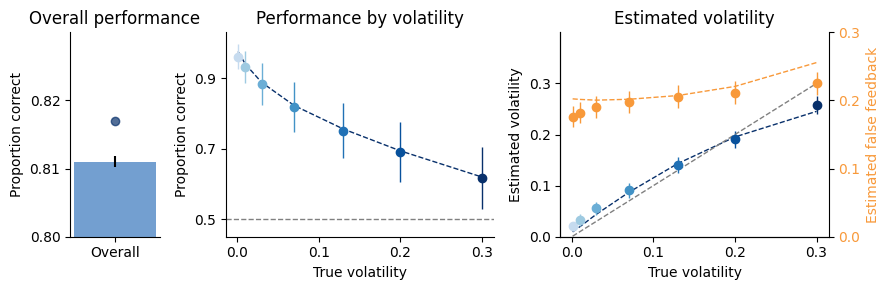

In [13]:
#sorted_bins = np.percentile(nus, np.linspace(0, 100, nb_bins_volatility + 1))
x_nus =  np.unique(nus)#[:-1] #(sorted_bins[:-1] + sorted_bins[1:]) / 2.

mean_vol_optim = nus_learned_optim.mean(axis=0)
mean_rewards_optim = out_rewards_nus_optim.mean(axis=0)
mean_falsefeedback_optim = nus_falsefeedback_learned_optim.mean(axis=0)
overall_mean_optim = performance_optim.mean()

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

fig, axs = plt.subplots(1, 3, figsize=(9, 3), gridspec_kw={'width_ratios': [1, 3, 3]})

# Subplot 1: overall performance barplot
overall_mean = performance.mean()
overall_std = performance.std() / np.sqrt(nb_simul)
axs[0].bar(0, overall_mean, yerr=overall_std, color="#3877BC", capsize=0, alpha=0.7)
axs[0].errorbar(0, overall_mean_optim, fmt='o', color=np.array([0.03137254901960784, 0.18823529411764706, 0.4196078431372549]), elinewidth=1, capsize=0, alpha=0.7)
axs[0].axhline(0.5, color='gray', linestyle='--', linewidth=1)
axs[0].set_ylim([0.8, 0.83])
axs[0].set_yticks([0.8, 0.81, 0.82])
axs[0].set_xticks([0])
axs[0].set_xticklabels(['Overall'])
axs[0].spines[['right', 'top']].set_visible(False)
axs[0].set_ylabel('Proportion correct')
axs[0].set_title('Overall performance')

# Subplot 2: errorbars by volatility (blues gradient for each)
mean_rewards = out_rewards_nus.mean(axis=0)
std_rewards = out_rewards_nus_stds.mean(axis=0) / np.sqrt(nb_simul)
n_bins = len(x_nus)
cmap = cm.get_cmap('Blues', n_bins + 2)  # +2 to not have white
vol_lines = []

for i in range(n_bins):
    color = cmap(i + 2)  # skip first two lightest
    h = axs[1].errorbar(
        x_nus[i],
        mean_rewards[i],
        yerr=std_rewards[i],
        fmt='o',
        color=color,
        ecolor=color,
        elinewidth=1,
        capsize=0,
        label=f'vol={x_nus[i]:.3f}' if i < 8 else None # only a few for legend
    )
    vol_lines.append(h)

axs[1].plot(x_nus, mean_rewards_optim[:len(x_nus)], color=color, linestyle='--', linewidth=1, zorder=1)

axs[1].axhline(0.5, color='gray', linestyle='--', linewidth=1)
axs[1].set_ylim([0.45, 1.03])
axs[1].set_yticks([0.5, 0.7, 0.9])
axs[1].spines[['right', 'top']].set_visible(False)
axs[1].set_xlabel('True volatility')
axs[1].set_ylabel('Proportion correct')
axs[1].set_title('Performance by volatility')
# Optionally: legend for colors in subplot 2
# axs[1].legend(loc="upper left", bbox_to_anchor=(1.05, 1), title="Volatility")

# Subplot 3: errorbars for estimated volatility (blues) and false feedback (orange, right)
mean_vol = nus_learned.mean(axis=0)
mean_falsefeedback = nus_falsefeedback_learned.mean(axis=0)
std_vol = nus_learned_stds.mean(axis=0) / np.sqrt(nb_simul)
std_falsefeedback = nus_falsefeedback_learned_stds.mean(axis=0) / np.sqrt(nb_simul)

ax3 = axs[2]
ax3b = ax3.twinx()

vol_lines_third = []
for i in range(n_bins):
    color = cmap(i + 2)
    h = ax3.errorbar(
        x_nus[i],
        mean_vol[i],
        yerr=std_vol[i],
        fmt='o',
        color=color,
        ecolor=color,
        elinewidth=1,
        capsize=0,
        label=f'vol={x_nus[i]:.3f}' if i < 8 else None
    )
    vol_lines_third.append(h)

ax3.plot(x_nus, mean_vol_optim[:len(x_nus)], color=color, linestyle='--', linewidth=1, zorder=1)

ax3.plot(x_nus, x_nus, color='gray', linestyle='--', linewidth=1, label='x = y')
ax3.set_yticks([0, 0.1, 0.2, 0.3])
ax3.set_xticks([0, 0.1, 0.2, 0.3])
ax3.set_ylim([0, 0.4])
ax3.spines[['right', 'top']].set_visible(False)
ax3.set_xlabel('True volatility')
ax3.set_ylabel('Estimated volatility')
ax3.set_title('Estimated volatility')

# Estimated false feedback errorbars (orange, right axis)
ax3b.errorbar(
    x_nus,
    mean_falsefeedback,
    yerr=std_falsefeedback,
    fmt='o',
    color="#F8993A",
    ecolor="#F8993A",
    elinewidth=1,
    capsize=0,
    label='Estimated false feedback'
)

# Dashed line between the estimated false feedback markers
ax3b.plot(x_nus, mean_falsefeedback_optim[:len(x_nus)], color="#F8993A", linestyle='--', linewidth=1, zorder=1)

ax3b.set_ylabel("Estimated false feedback", color="#F8993A")
ax3b.tick_params(axis='y', labelcolor="#F8993A")
ax3b.spines['top'].set_visible(False)
ax3b.set_yticks([0, 0.1, 0.2, 0.3])

# Optionally: show legend for the different blues
# Only label the first line to not overload the legend, or label each if desired:
# handles = [vol_lines_third[0].lines[0]]
# labels = [f"volatility bins" ]
# lines2, labels2 = ax3.get_legend_handles_labels()
# ax3.legend(lines2, labels2, loc="upper left")

plt.tight_layout()
plt.savefig("figures/estimated_mean_volatility_optimal_april2026.pdf")
plt.show()

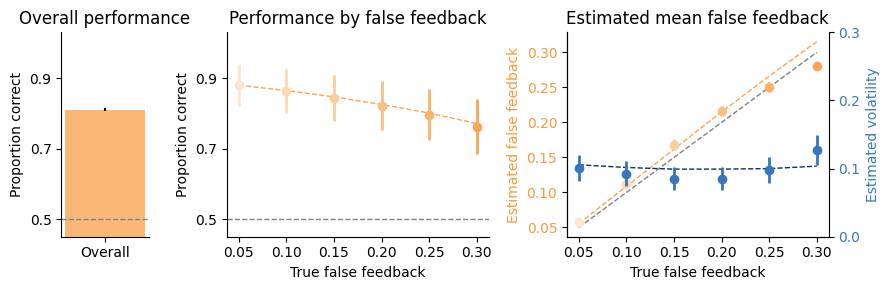

In [14]:
sorted_bins = np.percentile(false_positive_rate, np.linspace(0, 100, nb_bins_falsefeedback + 1))
x_falsefeedback = np.unique(false_positive_rate)[:-1] #(sorted_bins[:-1] + sorted_bins[1:]) / 2.


mean_falsefeedback_optim = false_positive_rate_learned_optim.mean(axis=0)
mean_rewards_optim = out_rewards_falsefeedback_optim.mean(axis=0)
mean_nus_optim = false_positive_rate_nus_learned_optim.mean(axis=0)
overall_mean_optim = performance_optim.mean()

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

fig, axs = plt.subplots(1, 3, figsize=(9, 3), gridspec_kw={'width_ratios': [1, 3, 3]})

# Subplot 1: overall performance barplot
overall_mean = out_rewards_falsefeedback.mean()
overall_std = out_rewards_falsefeedback.std() / np.sqrt(out_rewards_falsefeedback.size)
axs[0].bar(0, overall_mean, yerr=overall_std, color="#F8993A", capsize=0, alpha=0.7)
axs[0].axhline(0.5, color='gray', linestyle='--', linewidth=1)
axs[0].set_ylim([0.45, 1.03])
axs[0].set_yticks([0.5, 0.7, 0.9])
axs[0].set_xticks([0])
axs[0].set_xticklabels(['Overall'])
axs[0].spines[['right', 'top']].set_visible(False)
axs[0].set_ylabel('Proportion correct')
axs[0].set_title('Overall performance')

# Subplot 2: errorbars by false feedback (individual colored errorbars)
base_color = "#F8993A"
n_bins_ffb = len(x_falsefeedback)
colors = [mcolors.to_rgba(base_color, alpha=1.0)]
for i in range(1, n_bins_ffb + 2):
    interp = i / (n_bins_ffb + 2)
    color = mcolors.to_rgba(base_color, alpha=1.0)
    white = np.array([1, 1, 1, 1])
    color = tuple((1 - interp) * white + interp * np.array(color))
    colors.append(color)
errorbar_colors = [colors[i + 2] for i in range(n_bins_ffb)]  # skip lightest

mean_rewards = out_rewards_falsefeedback.mean(axis=0)
std_rewards = out_rewards_falsefeedback_stds.mean(axis=0) / np.sqrt(nb_simul)
for i, (x, m, s) in enumerate(zip(x_falsefeedback, mean_rewards, std_rewards)):
    axs[1].errorbar(
        x, m, yerr=s, fmt='o',
        color=errorbar_colors[i],
        ecolor=errorbar_colors[i],
        elinewidth=2,
        capsize=0,
    )

axs[1].plot(x_falsefeedback, mean_rewards_optim[:len(x_falsefeedback)], color=color, linestyle='--', linewidth=1, zorder=1)    
axs[1].axhline(0.5, color='gray', linestyle='--', linewidth=1)
axs[1].set_ylim([0.45, 1.03])
axs[1].set_yticks([0.5, 0.7, 0.9])
axs[1].spines[['right', 'top']].set_visible(False)
axs[1].set_xlabel('True false feedback')
axs[1].set_ylabel('Proportion correct')
axs[1].set_title('Performance by false feedback')

# Subplot 3: errorbars for inferred false feedback (estimates) and volatility estimate errorbars (blue)
mean_ffb = false_positive_rate_learned.mean(axis=0)
std_ffb = false_positive_rate_learned_stds.mean(axis=0) / np.sqrt(nb_simul)
for i, (x, m, s) in enumerate(zip(x_falsefeedback, mean_ffb, std_ffb)):
    axs[2].errorbar(
        x, m, yerr=s, fmt='o',
        color=errorbar_colors[i],
        ecolor=errorbar_colors[i],
        elinewidth=2,
        capsize=0,
        label=f"Estimated false feedback {x:.2f}" if i == 0 else None,  # label only once for legend
    )
axs[2].plot(x_falsefeedback, x_falsefeedback, color='gray', linestyle='--', linewidth=1, label='x = y')

axs[2].plot(x_falsefeedback, mean_falsefeedback_optim[:len(x_falsefeedback)], color=color, linestyle='--', linewidth=1, zorder=1)

# Volatility estimate as errorbars, as requested
mean_nu = false_positive_rate_nus_learned.mean(axis=0)
std_nu = false_positive_rate_nus_learned_stds.mean(axis=0) / np.sqrt(nb_simul)
axs2_right = axs[2].twinx()
for i, (x, m, s) in enumerate(zip(x_falsefeedback, mean_nu, std_nu)):
    axs2_right.errorbar(
        x, m, yerr=s, fmt='o',
        color="#3877BC",
        ecolor="#3877BC",
        elinewidth=2,
        capsize=0,
        label="Estimated volatility" if i == 0 else None,
    )

axs2_right.set_ylabel("Estimated volatility", color="#3877BC")
axs2_right.tick_params(axis='y', labelcolor="#3877BC")
axs2_right.spines['top'].set_visible(False)
axs2_right.set_yticks([0, 0.1, 0.2, 0.3])  # adjust y-ticks as needed
axs2_right.set_ylim([0, 0.3])

axs2_right.plot(x_falsefeedback, mean_nus_optim[:len(x_falsefeedback)], color=np.array([0.03137254901960784, 0.18823529411764706, 0.4196078431372549]), linestyle='--', linewidth=1, zorder=1)

axs[2].spines[['right', 'top']].set_visible(False)
axs[2].set_xlabel('True false feedback')
axs[2].set_ylabel('Estimated false feedback', color="#F8993A")
axs[2].set_title('Estimated mean false feedback')
axs[2].tick_params(axis='y', labelcolor="#F8993A")



plt.tight_layout()
plt.savefig("figures/estimated_false_feedback_optimal_april.pdf")
plt.show()

In [109]:
reversal_performance_means.shape

(10, 8, 20)

In [103]:
np.nanmean(reversal_performance, axis=1)

/var/folders/5j/f0qqpk592x36fxmyl_8vbkw40000gp/T/ipykernel_2540/3329227198.py:1: RuntimeWarning: Mean of empty slice
  np.nanmean(reversal_performance, axis=1)


array([[       nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan],
       [0.85585586, 0.83783784, 0.85585586, 0.85585586, 0.87387387,
        0.09459459, 0.22972973, 0.36486486, 0.44594595, 0.50900901,
        0.60810811, 0.65315315, 0.73873874, 0.7972973 , 0.84684685,
        0.83783784, 0.86036036, 0.82882883, 0.82432432, 0.83783784],
       [0.79971182, 0.79971182, 0.81556196, 0.80691643, 0.82132565,
        0.14985591, 0.28674352, 0.4092219 , 0.56772334, 0.63544669,
        0.69596542, 0.72766571, 0.74351585, 0.75792507, 0.76657061,
        0.78818444, 0.77521614, 0.79827089, 0.82564841, 0.82708934],
       [0.77137177, 0.75149105, 0.73624917, 0.75878065, 0.75016567,
        0.20079523, 0.40954274, 0.54141816, 0.63883366, 0.68323393,
        0.71040424, 0.72299536, 0.73889993, 0

In [96]:
unique_nus

array([0.  , 0.01, 0.03, 0.07, 0.1 , 0.15, 0.25, 0.4 ])

In [ ]:
(self.env.correct_arms == result['actions'].detach().numpy())

array([[ True,  True,  True, ..., False,  True, False],
       [False, False, False, ..., False, False, False],
       [ True, False,  True, ...,  True,  True,  True],
       ...,
       [False, False,  True, ...,  True, False,  True],
       [False,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]])

In [9]:
((result3['rewarded'] * (result3['logodds'].sign()).detach()) > 0).float().mean()

NameError: name 'result3' is not defined

In [55]:
result['rewarded']

tensor([ 1.,  1., -1., -1., -1., -1., -1.,  1.,  1.,  1., -1.,  1.,  1., -1.,
         1.,  1.,  1.,  1., -1.,  1., -1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
        -1., -1.,  1.,  1.,  1.,  1., -1.,  1., -1., -1., -1.,  1.,  1.,  1.,
         1.,  1.,  1., -1.,  1.,  1.,  1.,  1., -1.,  1.,  1.,  1.,  1.,  1.,
         1.,  1.,  1., -1.,  1.,  1.,  1., -1.,  1.,  1.,  1., -1.,  1., -1.,
        -1.,  1.,  1.,  1., -1.,  1., -1., -1.,  1.,  1., -1.,  1.,  1.,  1.,
        -1.,  1.,  1.,  1., -1.,  1.,  1.,  1.,  1.,  1., -1.,  1., -1., -1.,
         1.,  1., -1., -1., -1., -1.,  1., -1.,  1., -1., -1.,  1., -1., -1.,
        -1., -1.,  1.,  1.,  1.,  1.,  1.,  1., -1., -1.,  1., -1.,  1.,  1.,
        -1.,  1.,  1.,  1.,  1., -1., -1.,  1., -1.,  1., -1.,  1., -1.,  1.,
         1.,  1.,  1.,  1., -1.,  1., -1.,  1.,  1.,  1.,  1.,  1., -1.,  1.,
         1.,  1.,  1.,  1., -1., -1.,  1., -1., -1.,  1.,  1., -1.,  1.,  1.,
         1., -1., -1.,  1., -1.,  1., -1., -1.,  1.,  1.,  1., -

tensor([[ 0.,  1.,  1.,  1., -1.,  1., -1., -1.,  1.,  1., -1., -1.,  1.,  1.,
          1.,  1.,  1., -1., -1.,  1., -1., -1.,  1., -1.,  1.,  1.,  1.,  1.,
         -1., -1.,  1.,  1., -1.,  1.,  1.,  1.,  1., -1.,  1.,  1.,  1.,  1.,
         -1.,  1.,  1., -1.,  1.,  1.,  1., -1., -1.,  1.,  1.,  1.,  1.,  1.,
          1.,  1.,  1., -1.,  1.,  1.,  1., -1.,  1.,  1.,  1.,  1.,  1., -1.,
          1.,  1.,  1.,  1., -1.,  1.,  1.,  1.,  1.,  1., -1.,  1.,  1.,  1.,
          1., -1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1., -1., -1.,
          1.,  1., -1., -1.,  1., -1.,  1., -1.,  1.,  1., -1.,  1., -1.,  1.,
         -1., -1., -1.,  1.,  1.,  1.,  1., -1.,  1.,  1.,  1.,  1., -1., -1.,
         -1.,  1.,  1.,  1.,  1., -1., -1.,  1.,  1., -1., -1.,  1., -1.,  1.,
          1.,  1.,  1., -1., -1.,  1., -1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
          1.,  1., -1.,  1.,  1., -1.,  1., -1., -1.,  1.,  1., -1., -1.,  1.,
          1.,  1., -1.,  1., -1., -1., -1.,  1.,  1.

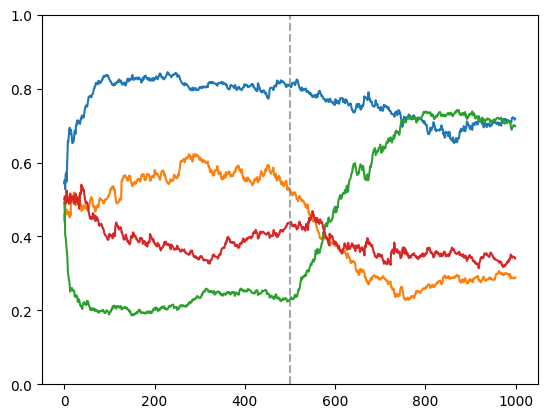

In [29]:
plt.figure()
plt.gca().set_ylim(0, 1)
plt.plot(torch.vstack([result['logits'], result2['logits']]).detach().numpy())
plt.axvline(x=500, color='grey', linestyle='--', alpha=0.7, label='500 Trials')

/var/folders/5j/f0qqpk592x36fxmyl_8vbkw40000gp/T/ipykernel_63521/1419712970.py:3: RuntimeWarning: Mean of empty slice
  plt.plot(np.nanmean(probabilities, axis=0))
/var/folders/5j/f0qqpk592x36fxmyl_8vbkw40000gp/T/ipykernel_63521/1419712970.py:4: RuntimeWarning: Mean of empty slice
  plt.fill_between(range(len(np.nanmean(probabilities, axis=0))),


TypeError: object of type 'numpy.float64' has no len()

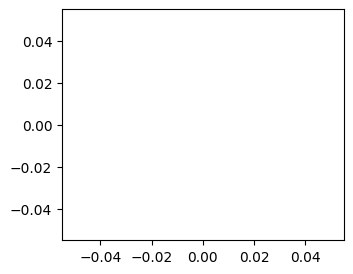

In [9]:
plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
plt.plot(np.nanmean(probabilities, axis=0))
plt.fill_between(range(len(np.nanmean(probabilities, axis=0))), 
                 np.nanmean(probabilities, axis=0) - np.nanstd(probabilities, axis=0) / np.sqrt(probabilities.shape[0]),
                 np.nanmean(probabilities, axis=0) + np.nanstd(probabilities, axis=0) / np.sqrt(probabilities.shape[0]),
                 alpha=0.3)
plt.xlabel('Sorted Probabilities')
plt.ylabel('Inferred Probabilities')
plt.subplot(1, 2, 2)
plt.plot(np.nanmean(variances, axis=0))
plt.fill_between(range(len(np.nanmean(variances, axis=0))), 
                 np.nanmean(variances, axis=0) - np.nanstd(variances, axis=0) / np.sqrt(variances.shape[0]),
                 np.nanmean(variances, axis=0) + np.nanstd(variances, axis=0) / np.sqrt(variances.shape[0]),
                 alpha=0.3)
plt.xlabel('Sorted Probabilities')
plt.ylabel('Variances')
plt.show()

In [65]:
outlist = []
nb_simul = 100
for nb_steps in [4, 8]:
    for i_simul in range(nb_simul):
        self.env.reset(num_trials=200, num_steps=1, num_tasks=1, reset_probas=True)
        result = self.evaluate()        
        self.env.reset(num_trials=200, num_steps=nb_steps, reset_probas=False, cond='Astar')
        test_result = self.evaluate(rnn_state=result['rnn_state'])
        max_perf = ((test_result['greedy'] * 2 - 1) == test_result['rewarded']).float().mean()
        agent_perf = ((test_result['logodds']).sign().detach() == test_result['rewarded']).float().mean()
        outlist.append([nb_steps, i_simul, float(max_perf), float(agent_perf)])
outdf = pd.DataFrame(outlist, columns=['nb_steps', 'i_simul', 'max_perf', 'agent_perf'])

/Users/csmfindling/Documents/Postdoc-Geneva/reliability_VW/reasoning/rnns/task.py:14: FutureWarning: arrays to stack must be passed as a "sequence" type such as list or tuple. Support for non-sequence iterables such as generators is deprecated as of NumPy 1.16 and will raise an error in the future.
  cues_presented = np.vstack(np.random.choice(list(cues) * (num_trials // len(cues)), size=num_trials, replace=False) for _ in range(num_tasks))


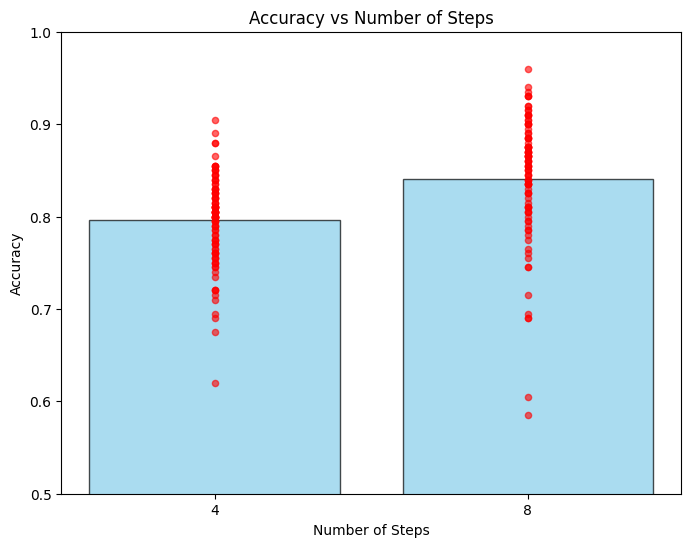

nb_steps
4    0.79600
8    0.84015
Name: agent_perf, dtype: float64

In [66]:
import matplotlib.pyplot as plt

# Group by number of steps and calculate mean accuracy
grouped = outdf.groupby('nb_steps')['agent_perf'].mean()

# Create bar plot
plt.figure(figsize=(8, 6))
bars = plt.bar([0, 1], grouped.values, alpha=0.7, color='skyblue', edgecolor='black')

# Add individual points
for pos,nb_steps in zip([0, 1], outdf['nb_steps'].unique()):
    step_data = outdf[outdf['nb_steps'] == nb_steps]['agent_perf']
    x_positions = [pos] * len(step_data)
    plt.scatter(x_positions, step_data, alpha=0.6, color='red', s=20)

plt.xlabel('Number of Steps')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Number of Steps')
plt.xticks([0, 1], ['4', '8'])
plt.ylim(0.5, 1.)
plt.show()

# Also display the grouped means
grouped

In [161]:
import pickle
[logodd_sequence_across_subjects_8, logodd_sequence_across_subjects_4] = pickle.load(
    open('/Users/csmfindling/Documents/Postdoc-Geneva/reliability_VW/reasoning/rnns/subject_tasks/subj_tasks.pkl', 'rb')
)

In [ ]:
tasks_8 = logodd_sequence_across_subjects_8[np.random.choice(np.arange(logodd_sequence_across_subjects_8.shape[0]), size=200, replace=False)]

array([[2, 0, 0, ..., 0, 3, 4],
       [4, 4, 3, ..., 2, 4, 4],
       [2, 0, 3, ..., 0, 3, 2],
       ...,
       [4, 2, 0, ..., 3, 2, 0],
       [3, 4, 3, ..., 0, 3, 2],
       [3, 3, 3, ..., 3, 2, 4]])

In [163]:
logodd_sequence_across_subjects_8.shape

(35, 120, 8)

In [227]:
from tqdm import tqdm
outlist = []
probalist = []
nb_simul = 35

for idx_simul in tqdm(range(1, 21)):

    self = Worker(
        probabilistic_task(),
        "results/source/saved_models",
        "rnn_pf_id{0}".format(idx_simul),
        "white",
        0.,
        nb_samples=-1,
        train_task="A",
        optimizer="Adam",
        init_type="xavier",
        episode_count_max=2e4,
        num_units=32,
        integration="optimal",
        loss_type="BCE",
        learn_variabilities=False
    )

    self.load_model()

    for nb_steps in [4, 8]:
        for i_simul in range(nb_simul):
            np.random.seed(i_simul * 2)
            torch.manual_seed(i_simul * 2)
            self.env.reset(num_trials=200, num_steps=1, num_tasks=1, reset_probas=True)
            result = self.evaluate()        
            
            #self.env.reset(num_trials=200, num_steps=nb_steps, reset_probas=False, cond='Astar')
            tasks = logodd_sequence_across_subjects_8[idx_simul] if nb_steps == 8 else logodd_sequence_across_subjects_4[idx_simul]      
            proba_tasks = np.round(1./(1. + np.exp(-tasks)), 1)
            squeezed_probas = np.round(self.env.probas.squeeze(), 2)
            sorter = np.argsort(squeezed_probas)
            self.env.context = torch.from_numpy(sorter[np.searchsorted(squeezed_probas[sorter], proba_tasks)])
            self.env.num_trials = 120
            self.env.num_steps = nb_steps
            self.env.cond = 'Astar'
            test_result = self.evaluate(rnn_state=result['rnn_state'])
            test_result['greedy'] = (tasks.sum(axis=1) > 0) * 1
            test_result['rewarded'] = (np.random.rand(120) < 1./(1. + np.exp(-tasks.sum(axis=1)))) * 2 - 1
            max_perf = ((test_result['greedy'] * 2 - 1) == test_result['rewarded']).mean()
            agent_perf = ((test_result['logodds']).squeeze().sign().detach().numpy() == test_result['rewarded']).mean()
            outlist.append([nb_steps, idx_simul, i_simul, float(max_perf), float(agent_perf)])    

            sorted_indices = np.argsort(result['probas'].squeeze())
            sorted_emissions = result['emission_probs'][sorted_indices]
            sorted_probas = result['probas'].squeeze()[sorted_indices]
            for i in range(len(sorted_emissions)):
                probalist.append([nb_steps, idx_simul, i_simul, float(sorted_emissions[i]), sorted_probas[i]])

outdf = pd.DataFrame(outlist, columns=['nb_steps', 'idx_simul', 'i_simul', 'max_perf', 'agent_perf'])
probadf = pd.DataFrame(probalist, columns=['nb_steps', 'idx_simul', 'i_simul', 'emission_probs', 'probas'])

  0%|          | 0/20 [00:00<?, ?it/s]/Users/csmfindling/Documents/Postdoc-Geneva/reliability_VW/reasoning/rnns/task.py:14: FutureWarning: arrays to stack must be passed as a "sequence" type such as list or tuple. Support for non-sequence iterables such as generators is deprecated as of NumPy 1.16 and will raise an error in the future.
  cues_presented = np.vstack(np.random.choice(list(cues) * (num_trials // len(cues)), size=num_trials, replace=False) for _ in range(num_tasks))
100%|██████████| 20/20 [00:43<00:00,  2.15s/it]


In [228]:
aggdf = outdf.groupby(['nb_steps', 'idx_simul'])[['agent_perf', 'max_perf']].mean().reset_index()
aggprobadf = probadf.groupby(['nb_steps', 'idx_simul', "probas"])[['emission_probs']].mean().reset_index()

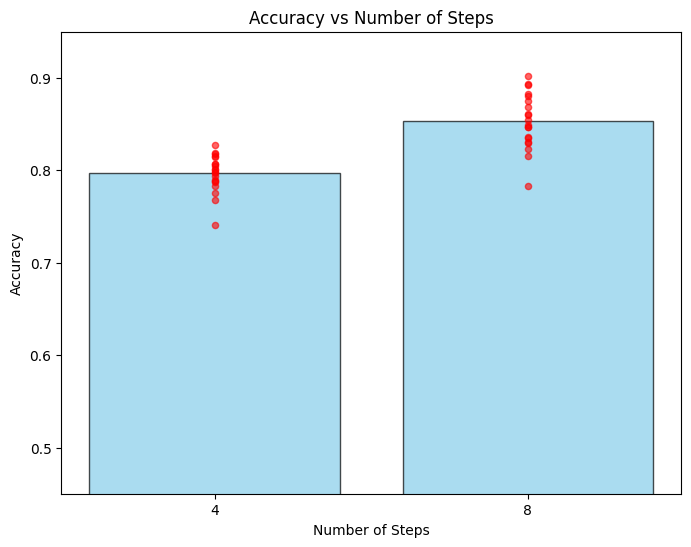

nb_steps
4    0.796857
8    0.853250
Name: agent_perf, dtype: float64

In [232]:
import matplotlib.pyplot as plt

# Group by number of steps and calculate mean accuracy
grouped = aggdf.groupby('nb_steps')['agent_perf'].mean()

# Create bar plot
plt.figure(figsize=(8, 6))
bars = plt.bar([0, 1], grouped.values, alpha=0.7, color='skyblue', edgecolor='black')

# Add individual points
for pos,nb_steps in zip([0, 1], aggdf['nb_steps'].unique()):
    step_data = aggdf[aggdf['nb_steps'] == nb_steps]['agent_perf']
    x_positions = [pos] * len(step_data)
    plt.scatter(x_positions, step_data, alpha=0.6, color='red', s=20)

plt.xlabel('Number of Steps')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Number of Steps')
plt.xticks([0, 1], ['4', '8'])
plt.ylim(0.45, .95)
plt.show()

# Also display the grouped means
grouped

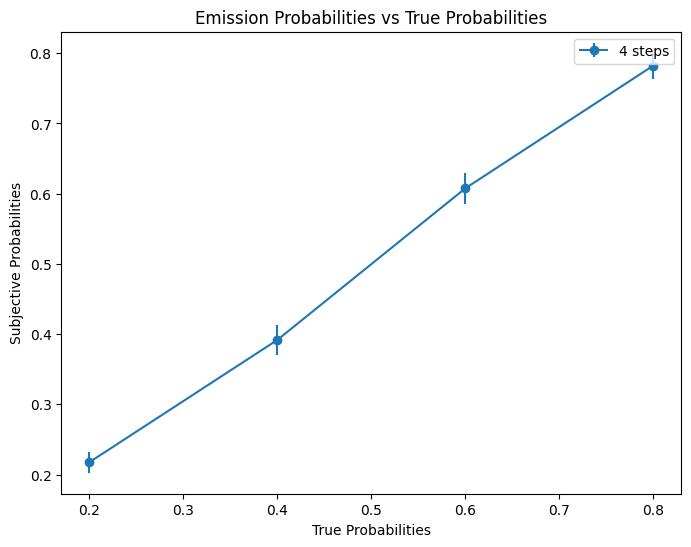

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate mean and SEM across idx_simul for each nb_steps and probas combination
plot_data = aggprobadf.groupby(['nb_steps', 'probas']).agg({
    'emission_probs': ['mean', 'std']
}).reset_index()

# Flatten column names
plot_data.columns = ['nb_steps', 'probas', 'emission_probs_mean', 'emission_probs_sem']

plt.figure(figsize=(8, 6))

# Plot for nb_steps=4
data_4 = plot_data[plot_data['nb_steps'] == 4]
plt.errorbar(data_4['probas'], data_4['emission_probs_mean'], 
             yerr=data_4['emission_probs_sem'], 
             label='4 steps', marker='o', capsize=0)

plt.xlabel('True Probabilities')
plt.ylabel('Subjective Probabilities')
plt.title('Emission Probabilities vs True Probabilities')
plt.legend()
plt.show()


In [242]:
subdata = plot_data[plot_data.nb_steps == 4]
subdata

coef_4_mean = subdata.emission_probs_mean.values
coef_4_std = subdata.emission_probs_sem.values

In [243]:
rewared_subjects_4 = aggdf[aggdf.nb_steps == 4].agent_perf.values
rewared_subjects_8 = aggdf[aggdf.nb_steps == 8].agent_perf.values

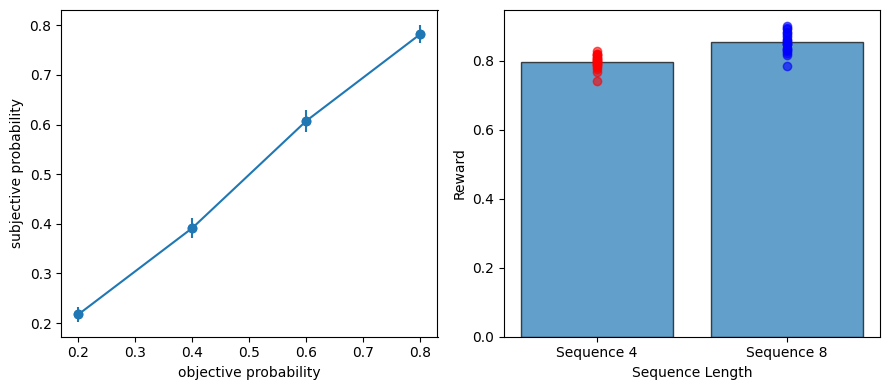

In [257]:
import matplotlib
import matplotlib.pyplot as plt

# This is the crucial line for PDF files
matplotlib.rcParams['pdf.fonttype'] = 42

# This is the equivalent for SVG files
matplotlib.rcParams['svg.fonttype'] = 'none'


plt.figure(figsize=(9, 4))
plt.subplot(1, 2, 1)
plt.scatter([0.2, 0.4, 0.6, 0.8], coef_4_mean)
plt.errorbar([0.2, 0.4, 0.6, 0.8], coef_4_mean, 
                yerr=coef_4_std, 
                label='4 steps', marker='o', capsize=0)
plt.ylabel('subjective probability')
plt.xlabel('objective probability')
plt.subplot(1, 2, 2)
plt.bar(['Sequence 4', 'Sequence 8'], [np.mean(rewared_subjects_4), np.mean(rewared_subjects_8[rewared_subjects_4 > 0.5])], alpha=0.7, edgecolor='black')
plt.scatter(['Sequence 4'] * len(rewared_subjects_4), rewared_subjects_4, alpha=0.6, color='red')
plt.scatter(['Sequence 8'] * len(rewared_subjects_8), rewared_subjects_8, alpha=0.6, color='blue')
plt.ylabel('Reward')
plt.xlabel('Sequence Length')
plt.tight_layout()
plt.savefig('/Users/csmfindling/Documents/Postdoc-Geneva/reliability_VW/expe/fig/subjects/performance_neuralHMM.pdf')
plt.show()


In [127]:
[probas[::-1], probas]

[array([0.8, 0.6, 0.4, 0.2]), array([0.2, 0.4, 0.6, 0.8])]